In [20]:
import qiskit
from qiskit import __version__
print(__version__)
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp, Pauli

import numpy as np
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib import cm

2.3.1


In [21]:
def cost_func_vqe(params, circuit, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (circuit, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    return cost

C:\Users\shlok\AppData\Local\Temp\ipykernel_37768\436763524.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  variational_form = TwoLocal(


[[1.9673793838736273,
  2.4343832614878873,
  0.6918660412832137,
  5.398905987771292,
  5.593700835381345,
  3.3626965716113055,
  4.830082253645645,
  1.0608131757410015]]

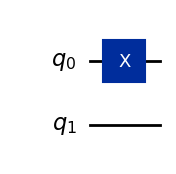

In [22]:
from qiskit.circuit.library import TwoLocal

observable = SparsePauliOp.from_list([("XX", 1), ("YY", -3)])

reference_circuit = QuantumCircuit(2)
reference_circuit.x(0)

variational_form = TwoLocal(
    2,
    rotation_blocks=["rz", "ry"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=1,
)
ansatz = reference_circuit.compose(variational_form)

theta_list = (2 * np.pi * np.random.rand(1, 8)).tolist()
display(theta_list)
display(reference_circuit.draw('mpl'))

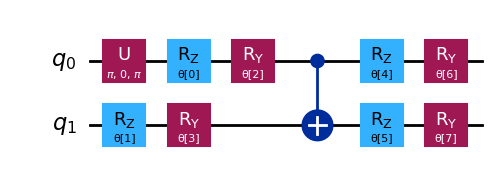

In [23]:
ansatz.decompose().draw("mpl")

In [24]:
estimator = StatevectorEstimator()
cost = cost_func_vqe(theta_list, ansatz, observable, estimator)
print(cost)

[0.94335947]
